In [1]:
import pandas as pd
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer

In [2]:
# ---------------------------------------------------------------------------
# 1. Leitura e limpeza dos dados
# ---------------------------------------------------------------------------
CAMINHO = "data/interim/dados_organizados.csv"

df = pd.read_csv(CAMINHO)
df

,Ano,Mes,Calc,COR(ppm Pt Co),TURB.(FTU),pH,ALC.(ppm CaCO3),AC.(ppm CaCO3),O.C.(ppm O2),DBO(ppm O2),...,P(ppm P),Cond.(uS/cm),Amonia(mg/l),Surfact.(mg/l),Cianobacteria(cel/ml),S.T.(mg/l),C.T.(NMP/100ml),C.F.(NMP/100ml),CLOROFILA(ug/l),F(ppm F)
0,2009,Jan,Mín.,200.0,64.0,"7,0",29,3,"6,3",--,...,--,131,NaN,--,6.600,--,50.000,23.000,"2,23","0,12"
1,2009,Jan,Méd.,432.0,131.0,"7,2",34,5,"6,8",--,...,--,145,NaN,--,6.850,--,50.000,23.000,"11,35","0,16"
2,2009,Jan,Máx.,690.0,241.0,"7,4",38,8,"7,5",--,...,--,156,NaN,--,7.100,--,50.000,23.000,"22,32","0,19"
3,2009,Fev,Mín.,393.0,72.0,"6,5",29,6,"5,9",--,...,--,128,NaN,--,1.100,--,240.000,30.000,"6,69","0,12"
4,2009,Fev,Méd.,868.0,238.0,"7,1",31,7,"7,2",--,...,--,133,NaN,--,2.100,--,240.000,30.000,"7,81","0,16"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571,2024,Nov,Méd.,217.0,134.0,"7,5",48,9,"9,7",-,...,"0,06",263,"2,00",-,-,-,-,3.000,"38,68","0,32"
572,2024,Nov,Máx.,805.0,746.0,"7,8",60,18,"17,6",-,...,"0,06",439,"4,39",-,-,-,-,3.000,"38,68","0,42"
573,2024,Dez,Mín.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
574,2024,Dez,Méd.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# usa apenas a estatística média mensal (192 meses, 2009-2024)
med = df[df["Calc"] == "Méd."].copy().reset_index(drop=True)

In [4]:
def to_num(s):
    """Converte texto no formato brasileiro ('1.110', '6,3', '--') para float."""
    s = str(s).strip().replace(".", "").replace(",", ".")
    try:
        return float(s)
    except ValueError:
        return np.nan

In [5]:
# variáveis físico-químicas completas usadas como preditoras no KNN
PRED = [
    "COR(ppm Pt Co)", "TURB.(FTU)", "pH", "ALC.(ppm CaCO3)", "AC.(ppm CaCO3)",
    "O.C.(ppm O2)", "O.D.(ppm O2)", "Cl-(ppm Cl-)", "DUR.(ppm CaCO3)",
    "Fe(ppm Fe)", "Mn(mg/l)", "Cond.(uS/cm)",
]

X = med[PRED].apply(lambda c: c.map(to_num))
# base "verdade": só meses completos nessas variáveis (gabarito p/ mascarar)
full = X.dropna().reset_index(drop=True)
print(f"Meses completos (base-verdade): {len(full)}")


Meses completos (base-verdade): 176


In [6]:
# ---------------------------------------------------------------------------
# 2. Configuração do experimento
# ---------------------------------------------------------------------------
ALVOS = ["COR(ppm Pt Co)", "TURB.(FTU)"]   # variáveis avaliadas
NIVEIS = [0.10, 0.20, 0.30]                  # taxas de falha (MCAR)
REPS = 30                                     # repetições por cenário


def metricas(y_true, y_pred):
    """RMSE, MAE e R² na escala original."""
    e = y_pred - y_true
    rmse = np.sqrt(np.mean(e ** 2))
    mae = np.mean(np.abs(e))
    ss = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - np.sum(e ** 2) / ss if ss > 0 else np.nan
    return rmse, mae, r2

In [7]:
# ---------------------------------------------------------------------------
# 3. Loop principal: mascarar -> imputar -> medir
# ---------------------------------------------------------------------------
linhas = []
for alvo in ALVOS:
    col = full.columns.get_loc(alvo)
    y = full[alvo].values
    n = len(y)
    rng_var = y.max() - y.min()          # range p/ normalizar RMSE/MAE (0-1)

    for p in NIVEIS:
        k = max(1, int(round(p * n)))    # nº de células a mascarar

        for metodo in ["media", "mediana", "KNN"]:
            R = []
            for r in range(REPS):
                # semente reprodutível por (nível, repetição)
                rng = np.random.default_rng(1000 * int(p * 100) + r)
                mask = rng.choice(n, size=k, replace=False)
                obs = np.setdiff1d(np.arange(n), mask)

                if metodo == "media":
                    imp = np.full(k, y[obs].mean())
                elif metodo == "mediana":
                    imp = np.full(k, np.median(y[obs]))
                else:  # KNN multivariado
                    Xm = full.values.astype(float).copy()
                    Xm[mask, col] = np.nan               # esconde as células-alvo
                    mu = np.nanmean(Xm, axis=0)
                    sd = np.nanstd(Xm, axis=0); sd[sd == 0] = 1
                    Xs = (Xm - mu) / sd                  # padroniza
                    Xi = KNNImputer(n_neighbors=7, weights="distance").fit_transform(Xs)
                    imp = (Xi * sd + mu)[mask, col]      # desfaz padronização

                R.append(metricas(y[mask], imp))

            R = np.array(R)
            rmse, mae, r2 = R.mean(0)
            r2_std = R[:, 2].std()
            linhas.append(dict(
                var=alvo.split("(")[0], nivel=int(p * 100), metodo=metodo,
                RMSE=rmse, MAE=mae, R2=r2, R2_std=r2_std,
                RMSE_n=rmse / rng_var, MAE_n=mae / rng_var,   # normalizados 0-1
            ))

res = pd.DataFrame(linhas)
res.to_csv("resultados_exp_norm.csv", index=False)
print(res[["var", "nivel", "metodo", "RMSE_n", "MAE_n", "R2"]].round(3).to_string(index=False))

  var  nivel  metodo  RMSE_n  MAE_n     R2
  COR     10   media   0.129  0.091 -0.098
  COR     10 mediana   0.136  0.085 -0.197
  COR     10     KNN   0.080  0.041  0.604
  COR     20   media   0.127  0.089 -0.057
  COR     20 mediana   0.137  0.086 -0.207
  COR     20     KNN   0.078  0.040  0.610
  COR     30   media   0.122  0.087 -0.029
  COR     30 mediana   0.129  0.080 -0.147
  COR     30     KNN   0.076  0.039  0.614
TURB.     10   media   0.190  0.148 -0.086
TURB.     10 mediana   0.204  0.135 -0.219
TURB.     10     KNN   0.113  0.070  0.617
TURB.     20   media   0.191  0.144 -0.064
TURB.     20 mediana   0.207  0.134 -0.231
TURB.     20     KNN   0.123  0.076  0.552
TURB.     30   media   0.189  0.143 -0.013
TURB.     30 mediana   0.205  0.128 -0.190
TURB.     30     KNN   0.119  0.070  0.601


Figura salva


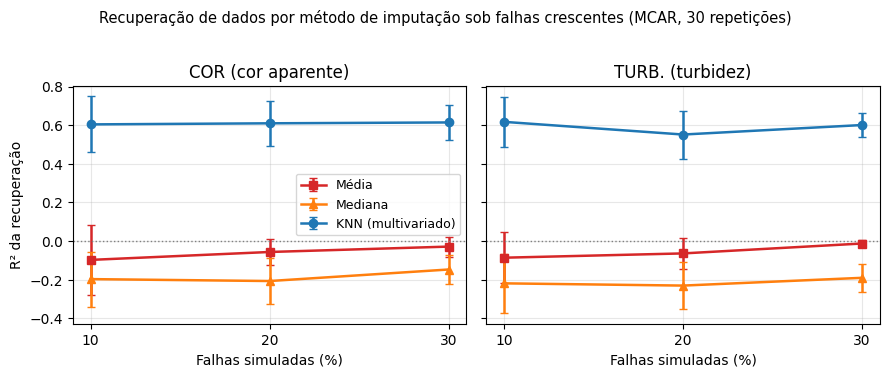

In [8]:
# ---------------------------------------------------------------------------
# 4. Figura: R² x % de falha (uma linha por método, dois painéis)
# ---------------------------------------------------------------------------
labels = {"media": "Média", "mediana": "Mediana", "KNN": "KNN (multivariado)"}
cores = {"media": "#d62728", "mediana": "#ff7f0e", "KNN": "#1f77b4"}
marc = {"media": "s", "mediana": "^", "KNN": "o"}
titulos = {"COR": "COR (cor aparente)", "TURB.": "TURB. (turbidez)"}

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
for ax, v in zip(axes, ["COR", "TURB."]):
    d = res[res["var"] == v]
    for m in ["media", "mediana", "KNN"]:
        dm = d[d["metodo"] == m].sort_values("nivel")
        ax.errorbar(dm["nivel"], dm["R2"], yerr=dm["R2_std"], marker=marc[m],
                    color=cores[m], label=labels[m], capsize=3, lw=1.8, ms=6)
    ax.axhline(0, color="gray", ls=":", lw=1)
    ax.set_title(titulos[v]); ax.set_xlabel("Falhas simuladas (%)")
    ax.set_xticks([10, 20, 30]); ax.grid(alpha=.3)
axes[0].set_ylabel("R² da recuperação")
axes[0].legend(fontsize=9, loc="center right")
fig.suptitle("Recuperação de dados por método de imputação sob falhas crescentes "
             "(MCAR, 30 repetições)", fontsize=10.5)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("figura_imputacao.png", dpi=200, bbox_inches="tight")
print("Figura salva")